# EV Market And Sales Analysis

The electric vehicle (EV) industry is evolving rapidly, driven by advancements in battery technology, shifting consumer preferences, and increasing competition among global manufacturers. But what truly defines success in this market? Is it performance, price, range or something deeper like brand power?

This notebook treats the dataset as an automotive market analytics case. The goal is to understand how EV pricing, range, battery capacity, charging, specifications and sales are related within the available data.

The analysis is intentionally data-bound: market interpretations are based on the dataset loaded in this notebook, not on external forecasts or unsupported claims.

In [1]:
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Import csv

In [3]:
df = pd.read_csv("data/ev_market_2026.csv")

In [4]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


In [6]:
df.duplicated().sum()

np.int64(0)

# EDA

In [7]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no=1

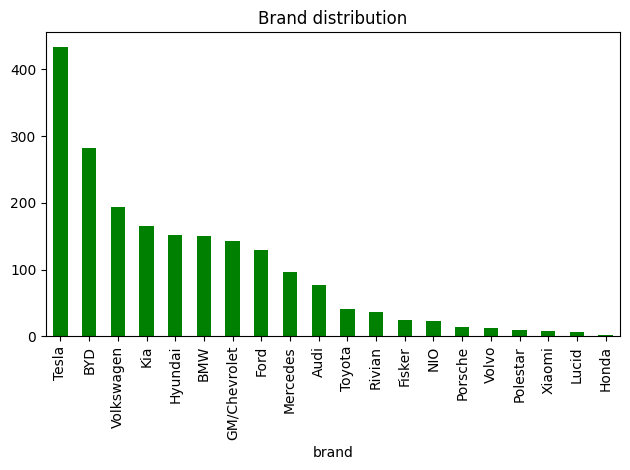

In [8]:
plt.figure()
df['brand'].value_counts().plot(kind='bar',color='green')
plt.title('Brand distribution')
show_fig()


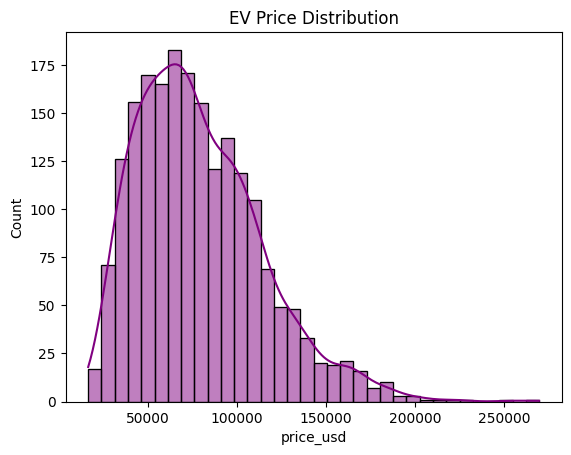

In [9]:
fig=plt.figure()
sns.histplot(df['price_usd'],kde=True,color='purple')
plt.title('EV Price Distribution')
plt.show()

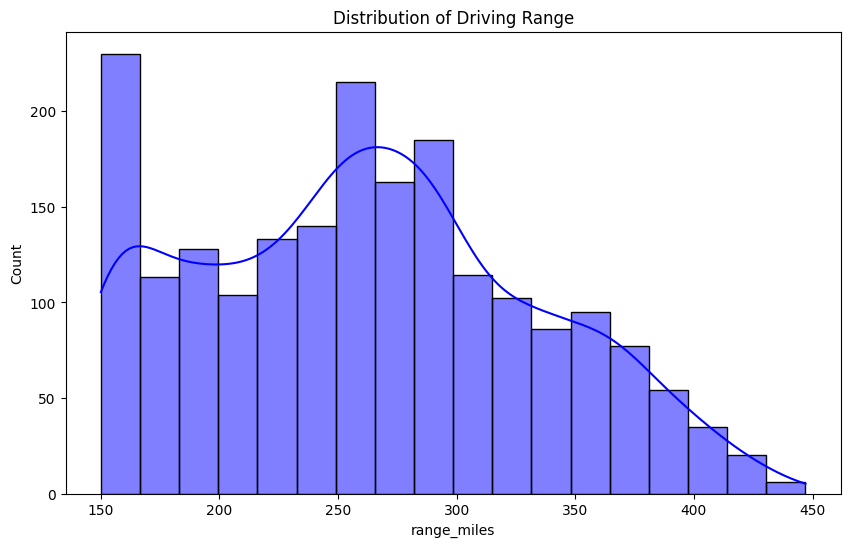

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['range_miles'],kde=True,color='blue')
plt.title('Distribution of Driving Range')
plt.show()

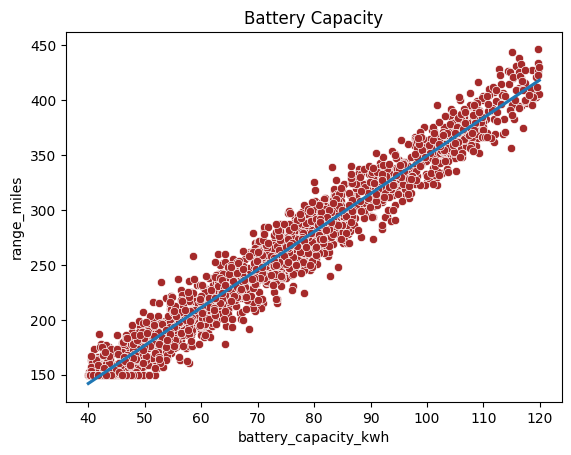

In [11]:
plt.figure()
sns.scatterplot(x='battery_capacity_kwh',y='range_miles',data=df,color='brown')
sns.regplot(x='battery_capacity_kwh',y='range_miles',data=df,scatter=False)
plt.title('Battery Capacity')
plt.show()

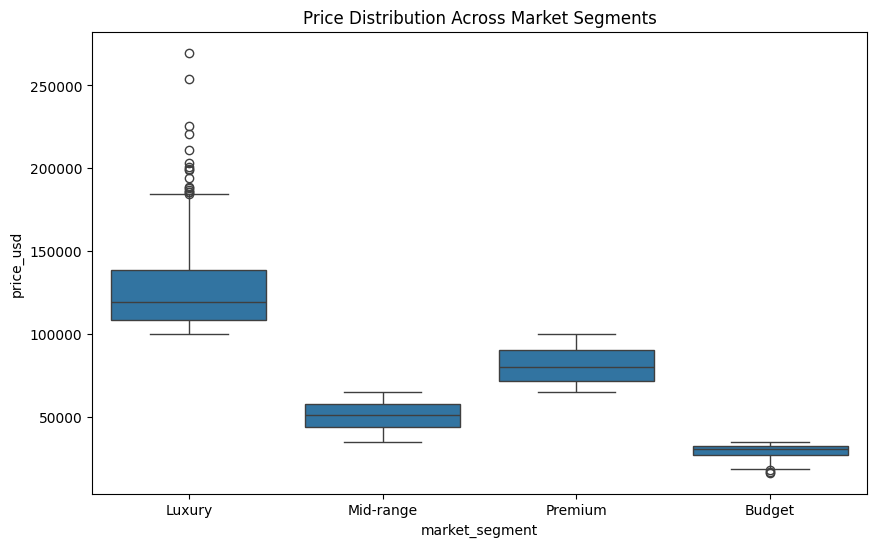

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(x='market_segment',y='price_usd',data=df)
plt.title('Price Distribution Across Market Segments')
plt.show()

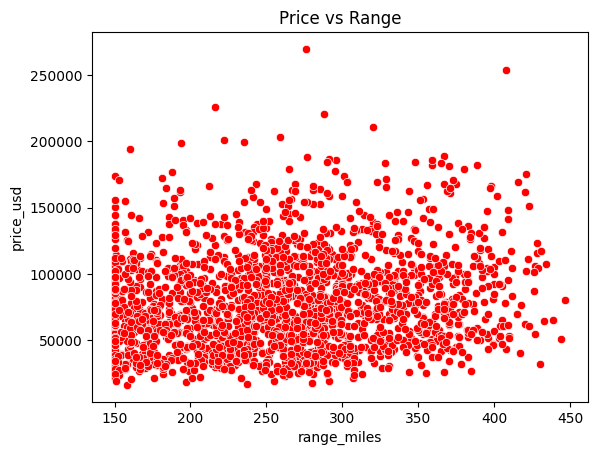

In [13]:
plt.figure()
sns.scatterplot(x='range_miles',y='price_usd',data=df,color='red')
plt.title('Price vs Range')
plt.show()

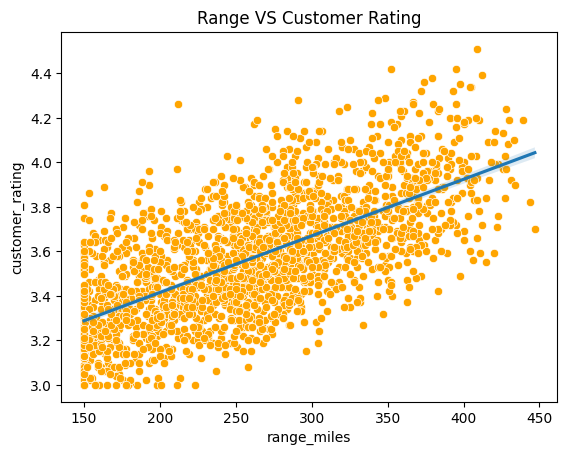

In [14]:
plt.figure()
sns.scatterplot(x='range_miles',y='customer_rating',data=df,color='orange')
sns.regplot(x='range_miles',y='customer_rating',data=df,scatter=False)
plt.title('Range VS Customer Rating')
plt.show()

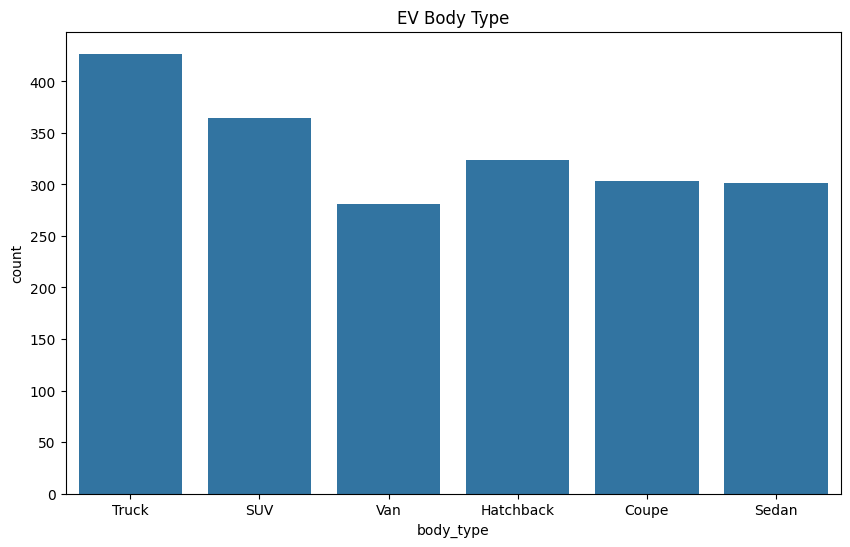

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x='body_type',data=df)
plt.title('EV Body Type')
plt.show()

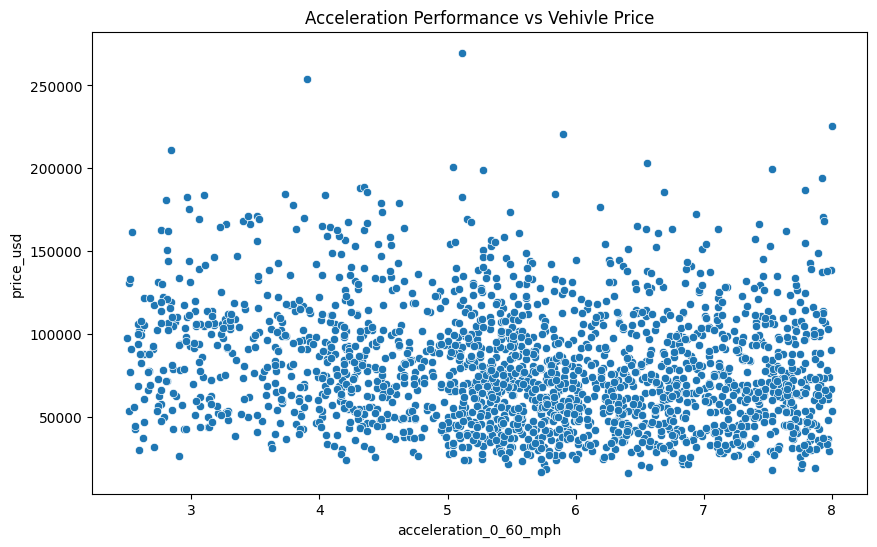

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='acceleration_0_60_mph',y='price_usd',data=df)
plt.title('Acceleration Performance vs Vehivle Price')
plt.show()

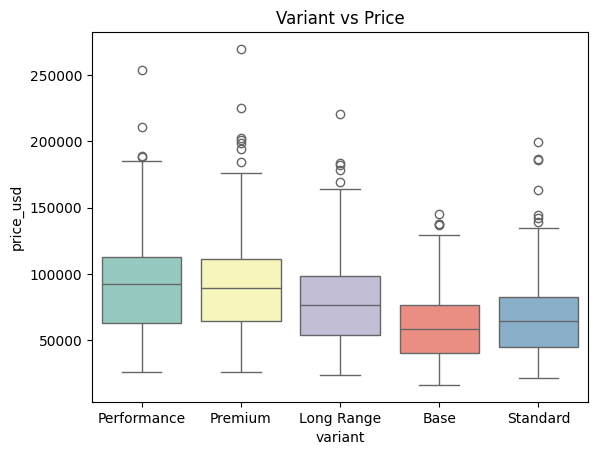

In [17]:
plt.figure()
sns.boxplot(x='variant',y='price_usd',data=df,palette='Set3')
plt.title('Variant vs Price')
plt.show()

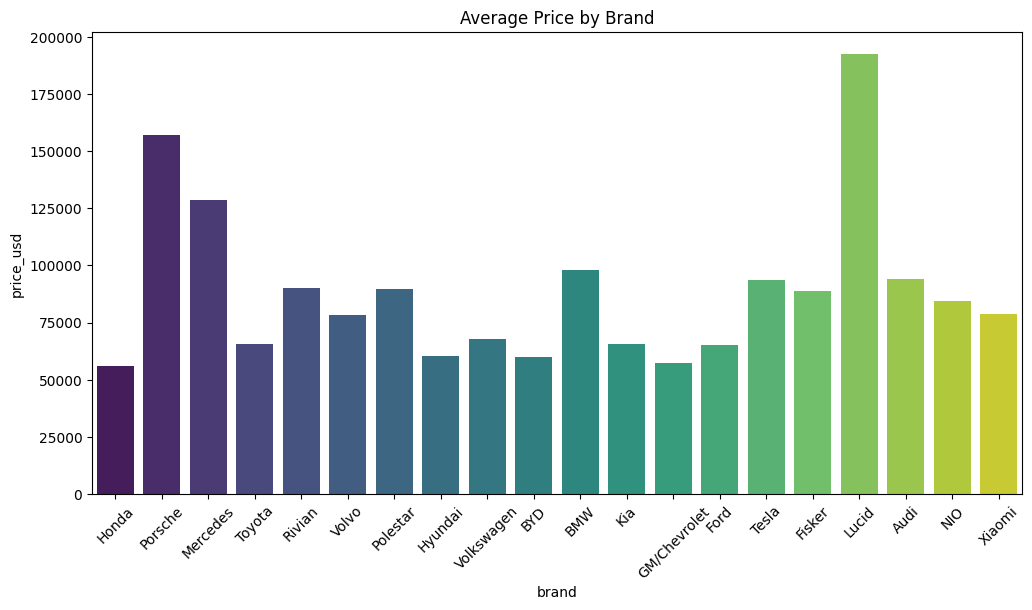

In [18]:
brand_stat = df.groupby('brand')[[
    'price_usd',
    'range_miles',
    'charging_speed_kw',
    'annual_sales_units']].mean().reset_index()

brand_stat_sorted = brand_stat.sort_values(by='range_miles', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=brand_stat_sorted,x='brand',y='price_usd',palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Price by Brand')
plt.show()

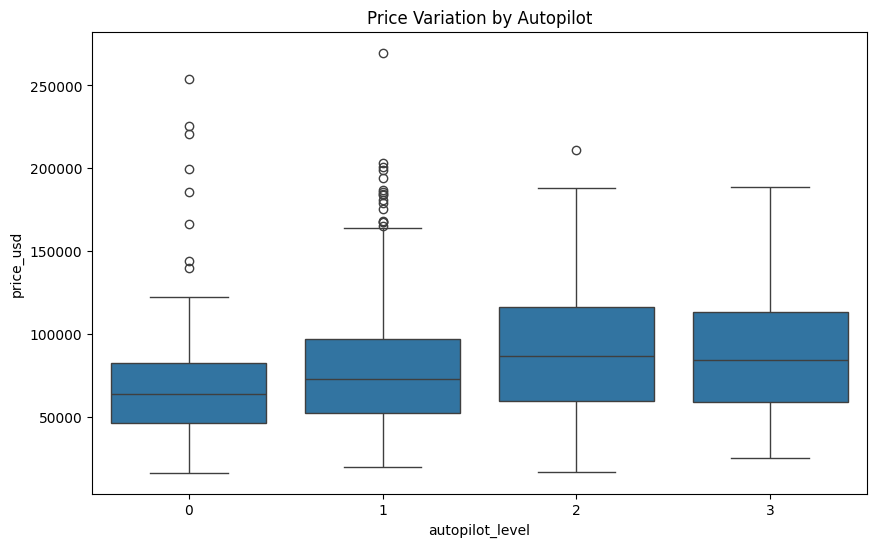

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x='autopilot_level',y='price_usd',data=df)
plt.title('Price Variation by Autopilot')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

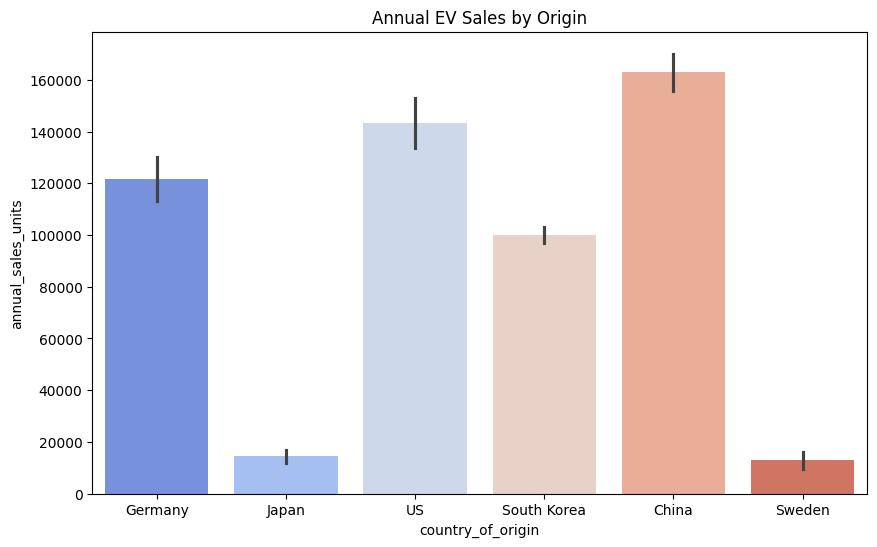

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x='country_of_origin',y='annual_sales_units',data=df,palette='coolwarm')
plt.title('Annual EV Sales by Origin')
plt.show

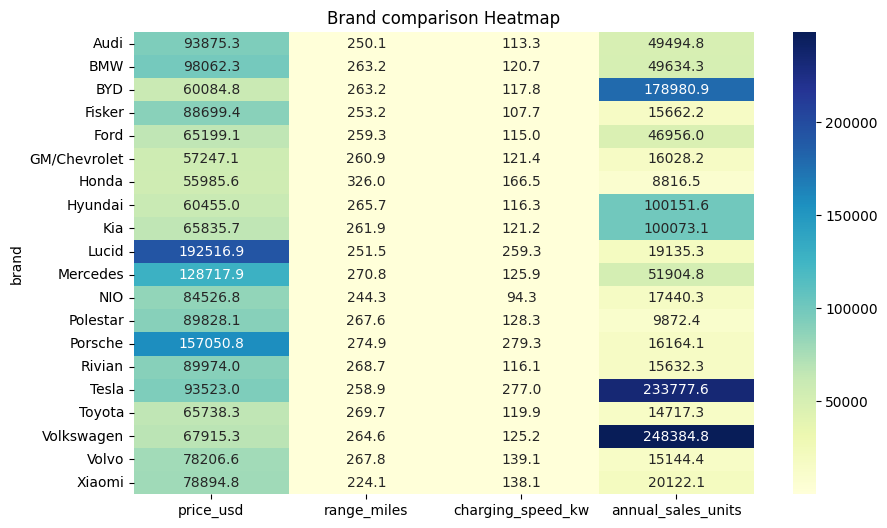

In [21]:
brand_heatmap=brand_stat.set_index('brand')
plt.figure(figsize=(10,6))
sns.heatmap(brand_heatmap,annot=True,cmap='YlGnBu',fmt='.1f')
plt.title('Brand comparison Heatmap')
plt.show()

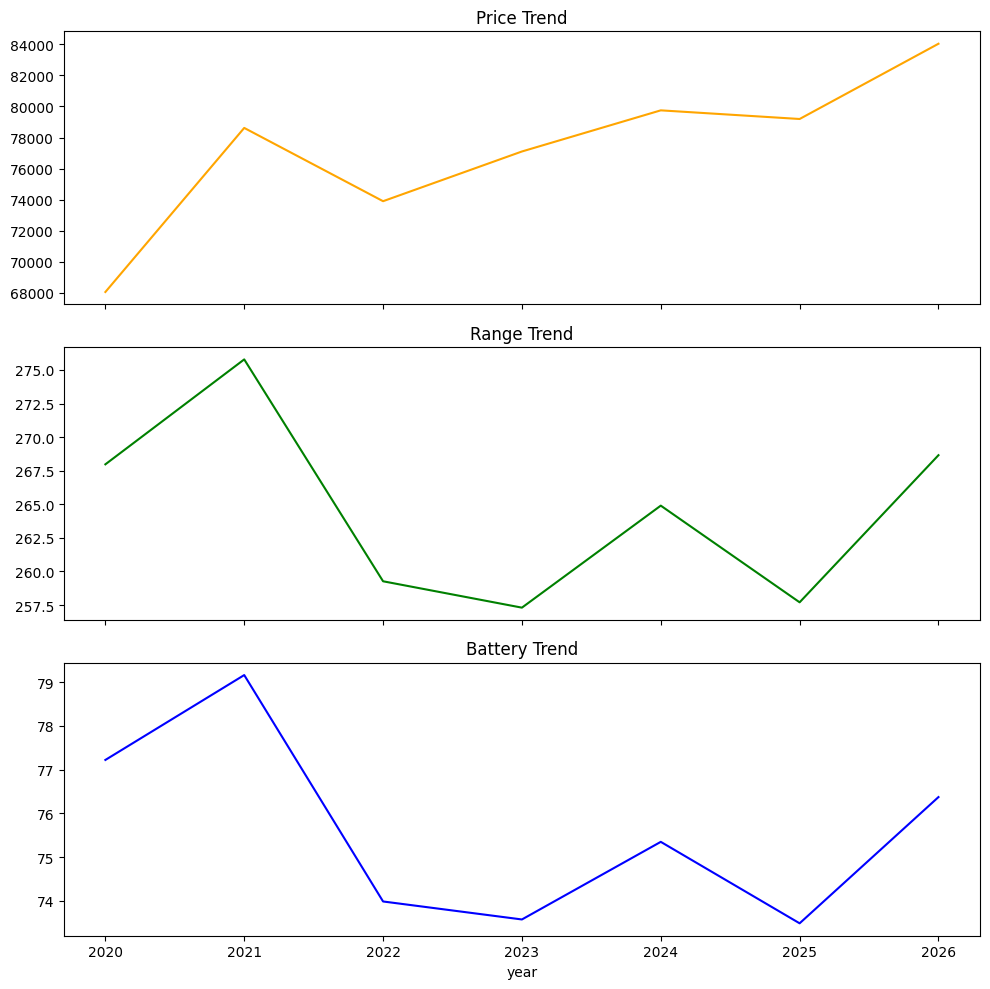

In [22]:
year_trend = df.groupby('year')[[
    'price_usd',
    'range_miles',
    'battery_capacity_kwh']].mean()

fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)

year_trend['price_usd'].plot(ax=axes[0], color='orange', title='Price Trend')
year_trend['range_miles'].plot(ax=axes[1], color='green', title='Range Trend')
year_trend['battery_capacity_kwh'].plot(ax=axes[2], color='blue', title='Battery Trend')

plt.tight_layout()
plt.show()

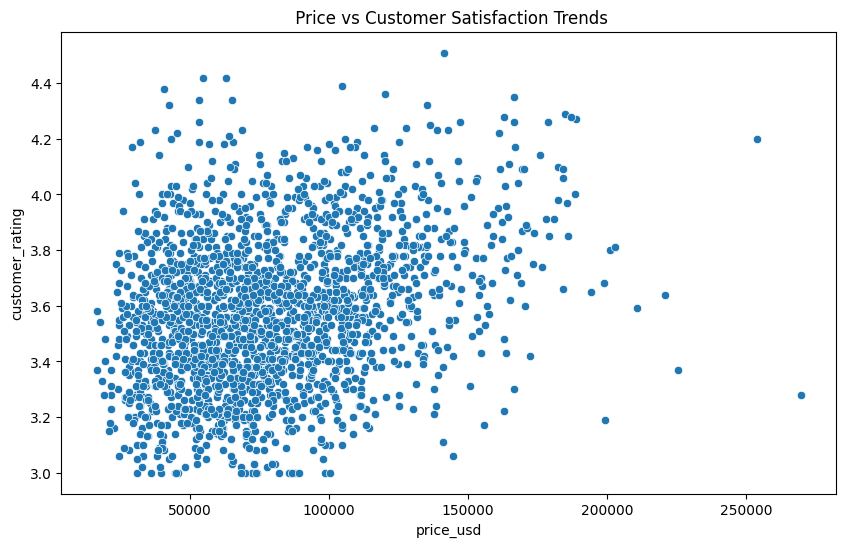

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='price_usd', y='customer_rating', data=df)
plt.title(' Price vs Customer Satisfaction Trends')
plt.show()

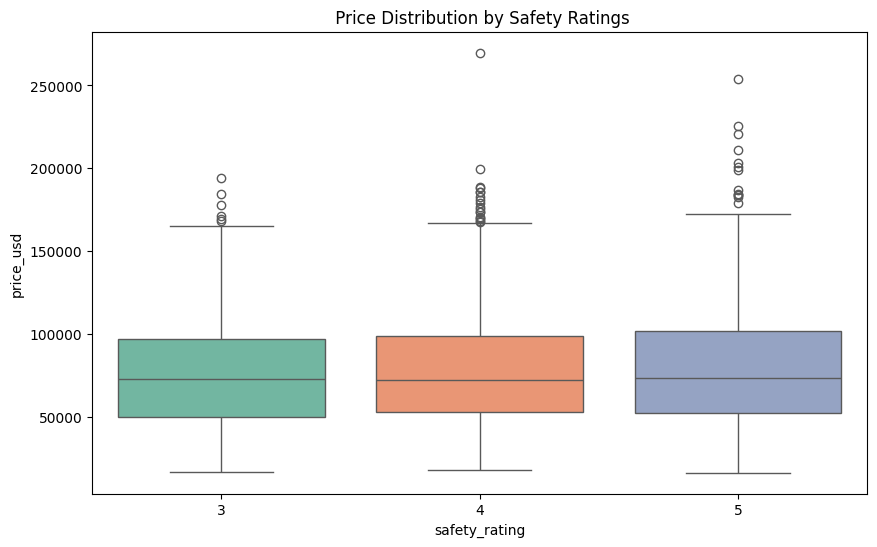

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x='safety_rating', y='price_usd', data=df,palette='Set2')
plt.title(' Price Distribution by Safety Ratings')
plt.show()

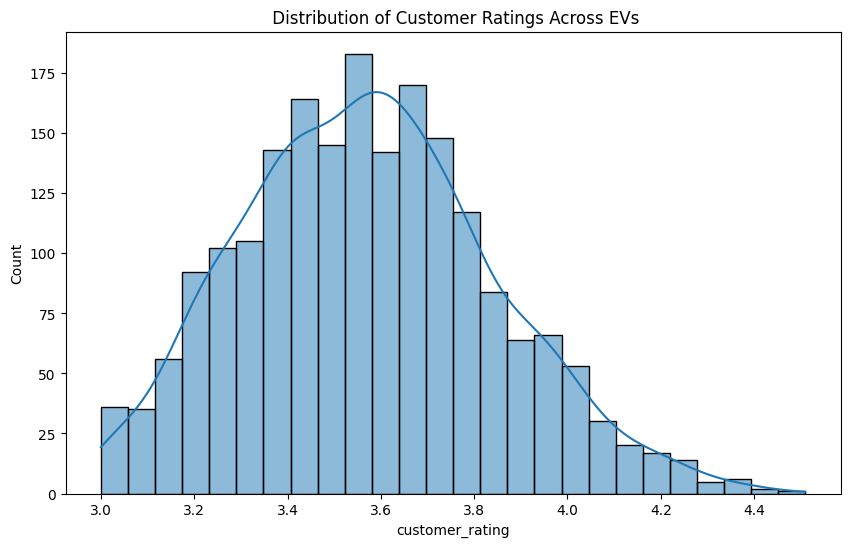

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['customer_rating'], kde=True)
plt.title(' Distribution of Customer Ratings Across EVs')
plt.show()

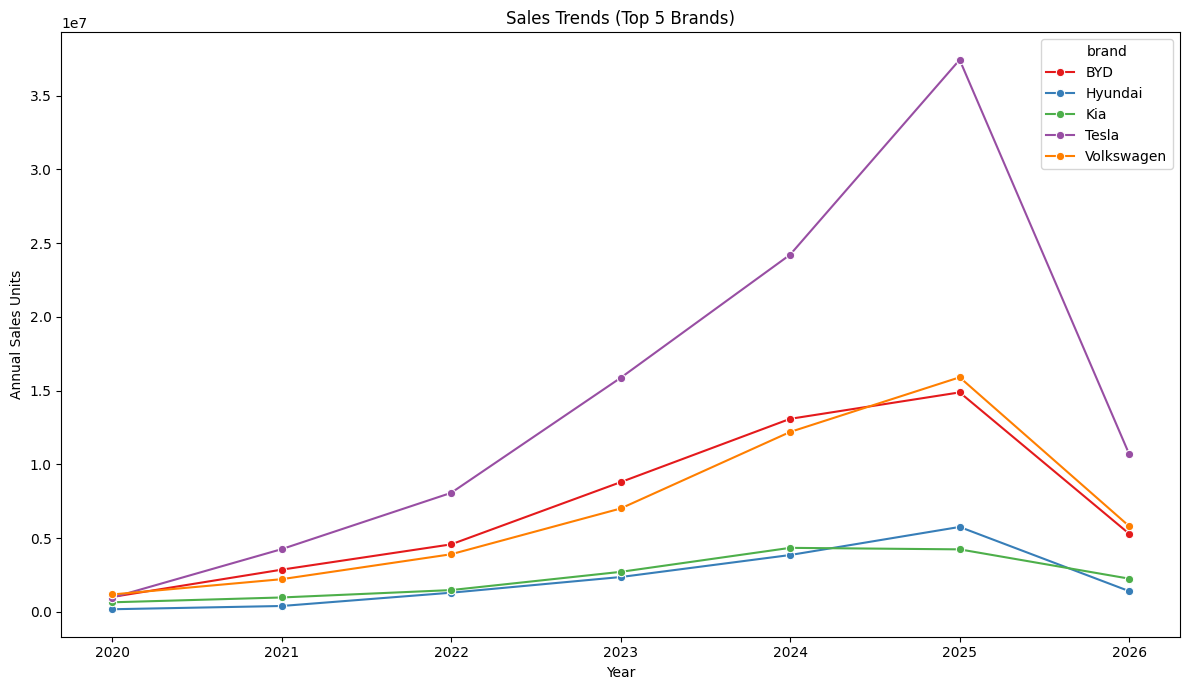

In [26]:
sale = df.groupby(['year','brand'])['annual_sales_units'].sum().reset_index()

top_brands = df.groupby('brand')['annual_sales_units'].sum().nlargest(5).index
filtered_sales = sale[sale['brand'].isin(top_brands)]

plt.figure(figsize=(12,7))

sns.lineplot(
    data=filtered_sales,
    x='year',
    y='annual_sales_units',
    hue='brand',
    marker='o',
    palette='Set1'
)

plt.title("Sales Trends (Top 5 Brands)")
plt.xlabel("Year")
plt.ylabel("Annual Sales Units")

plt.tight_layout()

In [27]:
df['value_score'] = df['range_miles'] / df['price_usd']

top_value = df.sort_values(by='value_score', ascending=False).head(10)

top_value[['brand','model','price_usd','range_miles','value_score']]

,brand,model,price_usd,range_miles,value_score
852,BYD,Qin,17777.32,280.0,0.015750
158,BYD,Seagull,19470.99,291.0,0.014945
1055,BYD,Seagull,16613.01,237.0,0.014266
1533,BYD,Qin,27057.77,385.0,0.014229
124,BYD,Qin,21712.40,307.0,0.014139
1775,BYD,Atto 3,26097.55,367.0,0.014063
1878,BYD,Atto 3,25253.73,355.0,0.014057
830,BYD,Atto 3,31933.47,430.0,0.013465
1021,BYD,Leaf 50X,25921.47,344.0,0.013271
617,BYD,Dolphin,19398.19,255.0,0.013146


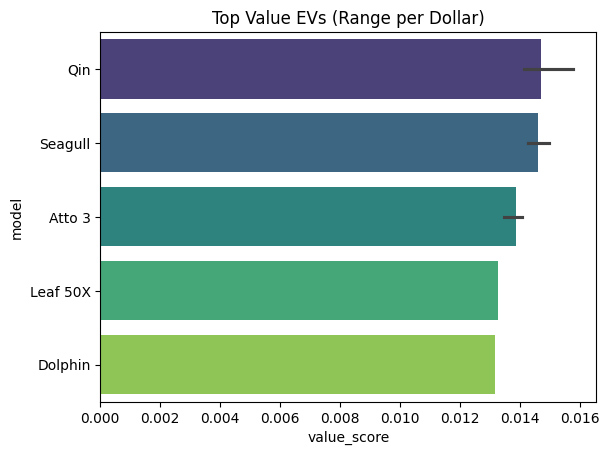

In [28]:
plt.figure()
sns.barplot(x='value_score', y='model', data=top_value, palette='viridis')
plt.title("Top Value EVs (Range per Dollar)")
plt.show()

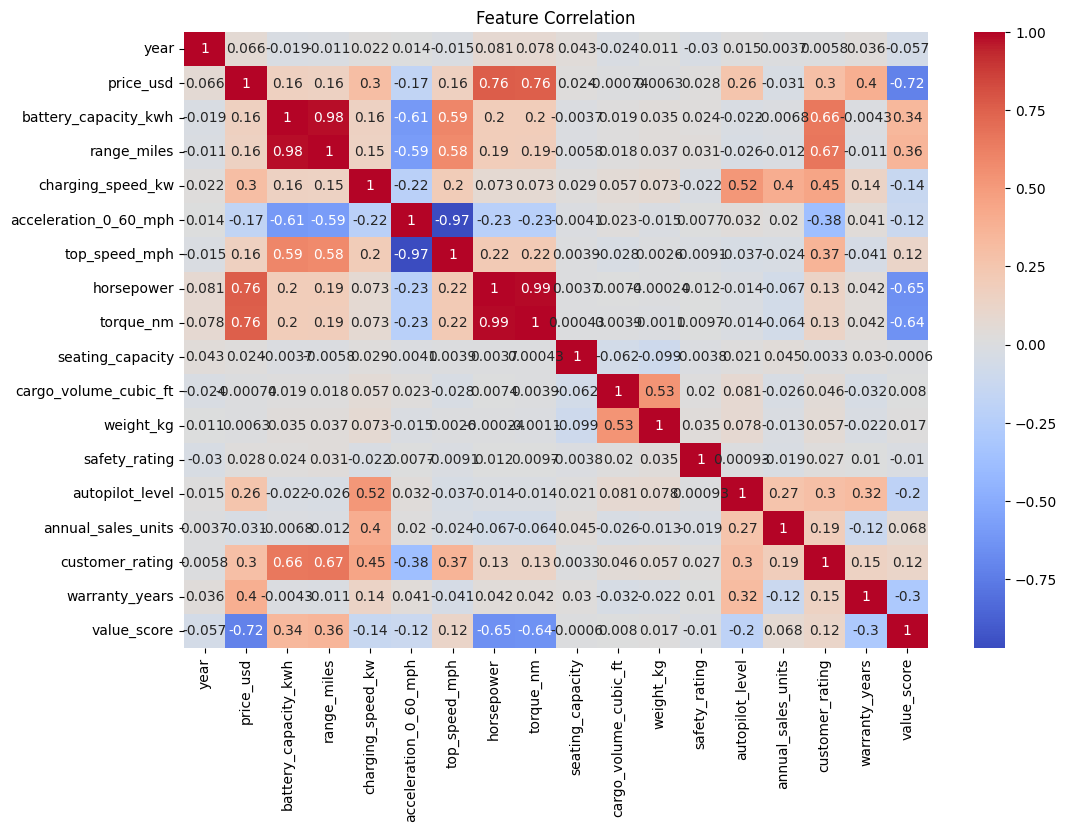

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years,value_score
year,1.000000,0.065604,-0.018653,-0.010605,0.022345,0.014385,-0.014974,0.080867,0.078481,0.043233,-0.023846,0.011005,-0.030302,0.015391,0.003734,0.005815,0.035789,-0.057217
price_usd,0.065604,1.000000,0.163565,0.156174,0.302888,-0.172457,0.164290,0.764724,0.759726,0.023512,-0.000737,0.006261,0.027652,0.257110,-0.030502,0.298409,0.396250,-0.721107
battery_capacity_kwh,-0.018653,0.163565,1.000000,0.977859,0.155309,-0.606528,0.592145,0.199032,0.197377,-0.003692,0.018981,0.034911,0.024168,-0.021736,-0.006791,0.658008,-0.004284,0.344650
range_miles,-0.010605,0.156174,0.977859,1.000000,0.148906,-0.592191,0.577426,0.192405,0.190323,-0.005804,0.018149,0.036884,0.030825,-0.026423,-0.012127,0.668137,-0.010557,0.359917
charging_speed_kw,0.022345,0.302888,0.155309,0.148906,1.000000,-0.222219,0.200766,0.073125,0.073153,0.028932,0.056504,0.073468,-0.022332,0.519870,0.401654,0.447148,0.135887,-0.136644
acceleration_0_60_mph,0.014385,-0.172457,-0.606528,-0.592191,-0.222219,1.000000,-0.970953,-0.227614,-0.226616,-0.004088,0.022828,-0.015251,0.007723,0.032428,0.019917,-0.377177,0.040619,-0.121445
top_speed_mph,-0.014974,0.164290,0.592145,0.577426,0.200766,-0.970953,1.000000,0.217379,0.216991,0.003859,-0.028282,0.002589,-0.009063,-0.036581,-0.023985,0.366117,-0.041165,0.123818
horsepower,0.080867,0.764724,0.199032,0.192405,0.073125,-0.227614,0.217379,1.000000,0.991827,0.003683,0.007445,-0.000243,0.012050,-0.014193,-0.067041,0.134986,0.042018,-0.651149
torque_nm,0.078481,0.759726,0.197377,0.190323,0.073153,-0.226616,0.216991,0.991827,1.000000,0.000426,0.003876,-0.001058,0.009741,-0.014091,-0.064073,0.132197,0.042297,-0.641779
seating_capacity,0.043233,0.023512,-0.003692,-0.005804,0.028932,-0.004088,0.003859,0.003683,0.000426,1.000000,-0.062495,-0.098862,-0.003792,0.021340,0.045239,0.003265,0.029833,-0.000596


In [29]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

corr

# Model Training

In [30]:
df_ml=df.copy()

for col in ['brand','model','variant','drive_type','body_type','market_segment','country_of_origin']:
    df_ml[col]=LabelEncoder().fit_transform(df_ml[col])

x=df_ml.drop('price_usd',axis=1)
y=df_ml['price_usd']

In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
df_ml['range_per_kwh']=df['range_miles']/df_ml['battery_capacity_kwh']
df_ml['power_to_weight']=df_ml['horsepower']/df_ml['weight_kg']

In [33]:
lr = LinearRegression()
lr.fit(x_train,y_train)

pred_lr=lr.predict(x_test)
print("Linear MAE:", mean_absolute_error(y_test,pred_lr))

Linear MAE: 8662.443152159522


In [34]:
rf= RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(x_train,y_train)

pred_rf=rf.predict(x_test)
print('RF MAE:',mean_absolute_error(y_test,pred_rf))

RF MAE: 3483.534908750001


<function matplotlib.pyplot.show(close=None, block=None)>

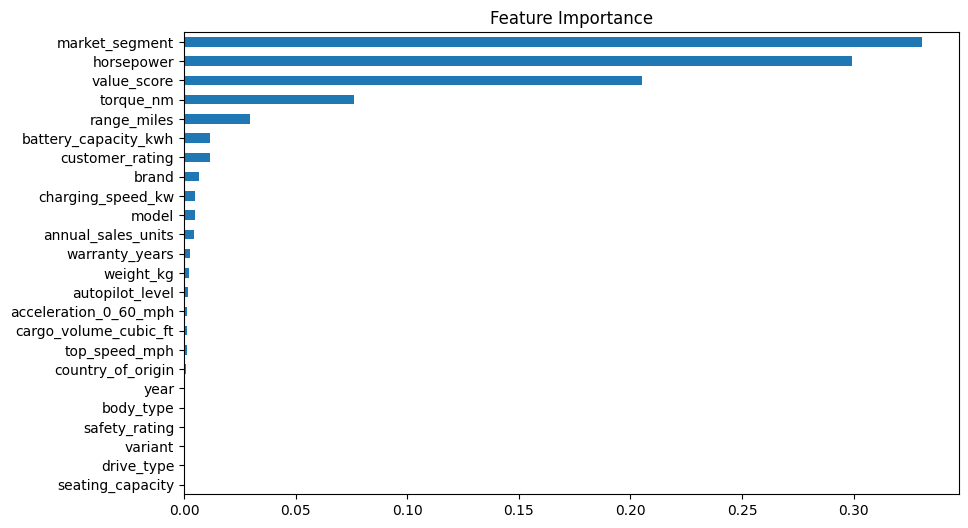

In [35]:
importance= pd.Series(rf.feature_importances_,index=x.columns)
importance.sort_values().plot(kind='barh',figsize=(10,6))
plt.title('Feature Importance')
plt.show

In [36]:
x_rating=df_ml.drop('customer_rating',axis=1)
y_rating=df_ml['customer_rating']


x_train,x_test,y_train,y_tesy=train_test_split(x_rating,y_rating,test_size=0.2)


In [37]:
rf.fit(x_train,y_train)
pred=rf.predict(x_test)

print("RF MAE:",mean_absolute_error(y_test,pred))

RF MAE: 77969.69524449999


In [38]:
y_sales=df_ml['annual_sales_units']
x_sales=df_ml.drop('annual_sales_units',axis=1)

x_train,x_test,y_train,y_test=train_test_split(x_sales,y_sales,test_size=0.2)

rf.fit(x_train,y_train)
pred=rf.predict(x_test)

print("RF MAE:", mean_absolute_error(y_test,pred))

RF MAE: 26030.68145


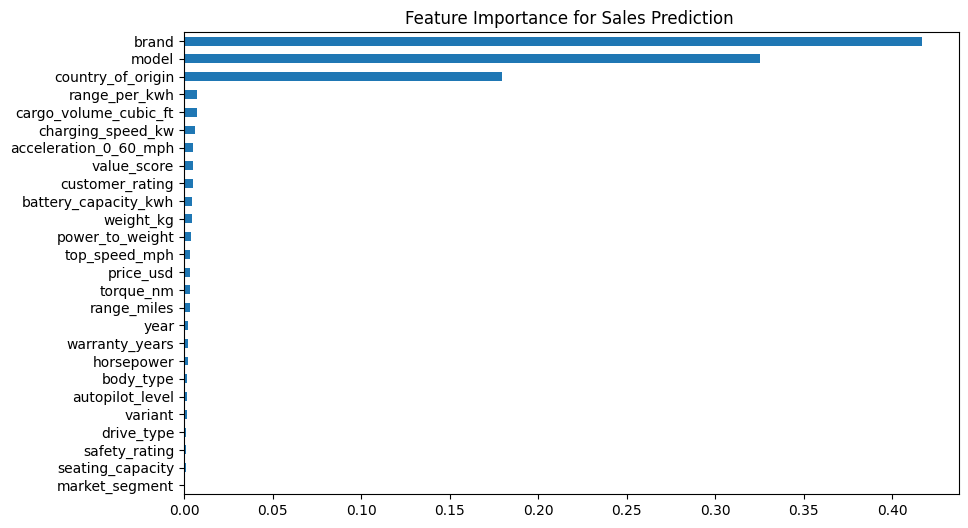

In [39]:
importance=pd.Series(rf.feature_importances_,index=x_sales.columns)

importance.sort_values().plot(kind='barh',figsize=(10,6))
plt.title('Feature Importance for Sales Prediction ')
plt.show()

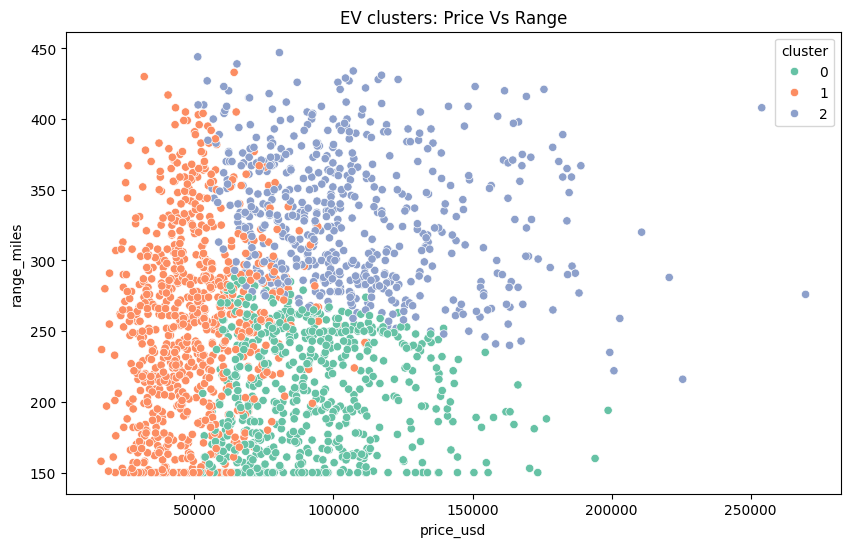

In [45]:
from sklearn.cluster import KMeans


df_cluster=df.copy()
features=df_cluster[['price_usd','range_miles','horsepower']]

scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)

kmeans=KMeans(n_clusters=3,n_init=10,random_state=42)
df_cluster['cluster']=kmeans.fit_predict(scaled_features)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cluster,x='price_usd',y='range_miles',hue='cluster',palette='Set2')

plt.title('EV clusters: Price Vs Range')
plt.show()

In [46]:
x=df.select_dtypes(include='number').drop(columns=['price_usd'])
y=df['price_usd']


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

scaler=StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

model=LinearRegression()
model.fit(x_train_scale,y_train)

y_pred =model.predict(x_test_scale)

r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

print("R2 Score:",r2)
print("MSE:",mse)

R2 Score: 0.8156877331220477
MSE: 233513885.31223038


**Actual vs Predict Plot**

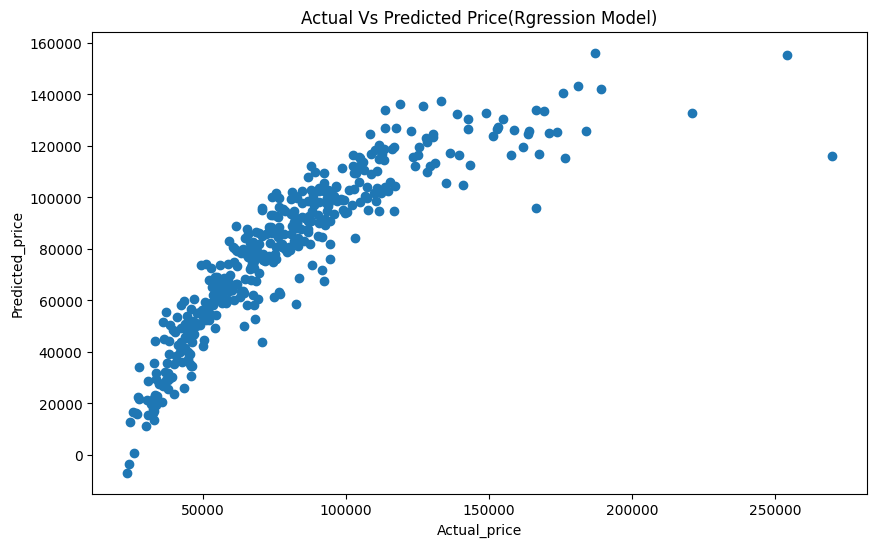

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual_price")
plt.ylabel("Predicted_price")
plt.title("Actual Vs Predicted Price(Rgression Model)")
plt.show()

In [43]:
df['value_score'] = df['range_miles'] / df['price_usd']

top_value = df.sort_values(by='value_score', ascending=False).head(10)

top_value[['brand','model','price_usd','range_miles','value_score']]



,brand,model,price_usd,range_miles,value_score
852,BYD,Qin,17777.32,280.0,0.015750
158,BYD,Seagull,19470.99,291.0,0.014945
1055,BYD,Seagull,16613.01,237.0,0.014266
1533,BYD,Qin,27057.77,385.0,0.014229
124,BYD,Qin,21712.40,307.0,0.014139
1775,BYD,Atto 3,26097.55,367.0,0.014063
1878,BYD,Atto 3,25253.73,355.0,0.014057
830,BYD,Atto 3,31933.47,430.0,0.013465
1021,BYD,Leaf 50X,25921.47,344.0,0.013271
617,BYD,Dolphin,19398.19,255.0,0.013146


In [44]:
def recommend_ev(max_price, min_range):
    return df[(df['price_usd'] <= max_price) & 
              (df['range_miles'] >= min_range)].sort_values(by='value_score', ascending=False).head(5)

recommend_ev(50000, 300)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years,value_score
1533,BYD,Qin,2023,Long Range,27057.77,108.5,385.0,77.2,5.89,162.0,...,31.5,1500.0,4,1,China,Budget,176350,3.60,4,0.014229
124,BYD,Qin,2024,Standard,21712.40,83.3,307.0,77.1,5.75,171.0,...,78.2,1628.0,4,0,China,Budget,169389,3.37,3,0.014139
1775,BYD,Atto 3,2025,Long Range,26097.55,99.0,367.0,56.9,4.77,176.0,...,71.7,2861.0,5,2,China,Budget,233286,3.51,5,0.014063
1878,BYD,Atto 3,2024,Long Range,25253.73,99.1,355.0,139.7,5.45,167.0,...,73.4,1891.0,4,0,China,Budget,158999,3.61,4,0.014057
830,BYD,Atto 3,2026,Performance,31933.47,119.9,430.0,171.3,2.71,200.0,...,20.7,1500.0,3,0,China,Budget,219100,4.19,5,0.013465


# Final Insights & Key Takeaways

This analysis reveals a clear and structured view of the EV market, highlighting both technological and market-driven dynamics:
* EV prices vary significantly across market segments.
* Battery capacity and range show a positive relationship.
* Luxury and performance segments tend to have higher prices.
* Price per mile is useful for comparing value across models.
* Some numerical columns contain outliers, but they appear realistic for EV market data.
  

**Customer Satisfaction**
* Range emerges as the strongest driver of customer ratings, highlighting the importance of reducing range anxiety.
* Other factors such as charging speed and warranty contribute, but play secondary roles.

***Final Conclusion***

While EV technology continues to advance, the market is shaped just as much by perception and positioning as by engineering. Consumers may value range and performance but ultimately, brand trust and value proposition define success in the EV industry.